In [10]:
import numpy as np
from pycocotools.coco import COCO
from pathlib import Path
import os
from tqdm.auto import tqdm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import math 

### VinDrCXR Annotations Processing

In [11]:
train_annotations = pd.read_csv("/kaggle/input/datasets/thebeo182004/vindr-cxr-annotations/annotations_train.csv")
test_annotations = pd.read_csv("/kaggle/input/datasets/thebeo182004/vindr-cxr-annotations/annotations_test.csv")

train_meta = pd.read_csv("/kaggle/input/datasets/thebeo182004/vindrcxr-meta/train_meta.csv")
test_meta = pd.read_csv("/kaggle/input/datasets/thebeo182004/vindrcxr-meta/test_meta.csv")

train_df = pd.merge(train_annotations, train_meta, on='image_id')
test_df = pd.merge(test_annotations, test_meta, on='image_id')

In [12]:
train_df['train'] = True
train_df.head()

,image_id,rad_id,class_name,x_min,y_min,x_max,y_max,dim0,dim1,train
0,000434271f63a053c4128a0ba6352c7f,R2,No finding,NaN,NaN,NaN,NaN,2836,2336,True
1,000434271f63a053c4128a0ba6352c7f,R3,No finding,NaN,NaN,NaN,NaN,2836,2336,True
2,000434271f63a053c4128a0ba6352c7f,R6,No finding,NaN,NaN,NaN,NaN,2836,2336,True
3,00053190460d56c53cc3e57321387478,R11,No finding,NaN,NaN,NaN,NaN,2430,1994,True
4,00053190460d56c53cc3e57321387478,R2,No finding,NaN,NaN,NaN,NaN,2430,1994,True


In [13]:
test_df['train'] = False
test_df.head()

,image_id,class_name,x_min,y_min,x_max,y_max,dim0,dim1,train
0,e0dc2e79105ad93532484e956ef8a71a,Calcification,1221.560976,661.580417,1343.298780,783.318222,2420,2148,False
1,e0dc2e79105ad93532484e956ef8a71a,Cardiomegaly,638.695122,1310.848710,1800.737805,1937.982856,2420,2148,False
2,e0dc2e79105ad93532484e956ef8a71a,ILD,1693.756098,1392.007246,1929.853659,1941.671881,2420,2148,False
3,e0dc2e79105ad93532484e956ef8a71a,Pneumothorax,399.924053,145.803282,1016.600328,510.138208,2420,2148,False
4,e0dc2e79105ad93532484e956ef8a71a,Pneumothorax,334.300846,493.762382,453.145487,744.509170,2420,2148,False


In [14]:
train_df.drop(columns=['rad_id'], inplace=True)
train_df.head()

,image_id,class_name,x_min,y_min,x_max,y_max,dim0,dim1,train
0,000434271f63a053c4128a0ba6352c7f,No finding,NaN,NaN,NaN,NaN,2836,2336,True
1,000434271f63a053c4128a0ba6352c7f,No finding,NaN,NaN,NaN,NaN,2836,2336,True
2,000434271f63a053c4128a0ba6352c7f,No finding,NaN,NaN,NaN,NaN,2836,2336,True
3,00053190460d56c53cc3e57321387478,No finding,NaN,NaN,NaN,NaN,2430,1994,True
4,00053190460d56c53cc3e57321387478,No finding,NaN,NaN,NaN,NaN,2430,1994,True


In [15]:
vindrcxr_df = pd.concat([train_df, test_df], axis=0)
len(vindrcxr_df['image_id'].unique().tolist())

18000

In [16]:
vindrcxr_df = vindrcxr_df[vindrcxr_df['class_name'] != "No finding"]
vindrcxr_df.reset_index(drop=True, inplace=True)
vindrcxr_df.head()

,image_id,class_name,x_min,y_min,x_max,y_max,dim0,dim1,train
0,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,900.956970,587.809021,1205.359985,888.710999,3072,3072,True
1,0005e8e3701dfb1dd93d53e2ff537b6e,Lung Opacity,900.956970,587.809021,1205.359985,888.710999,3072,3072,True
2,0005e8e3701dfb1dd93d53e2ff537b6e,Consolidation,932.471985,567.778992,1197.770020,896.408997,3072,3072,True
3,0005e8e3701dfb1dd93d53e2ff537b6e,Nodule/Mass,932.471985,567.778992,1197.770020,896.408997,3072,3072,True
4,0005e8e3701dfb1dd93d53e2ff537b6e,Lung Opacity,905.224976,583.223999,1203.270020,890.148010,3072,3072,True


In [17]:
transformed_width = 1024 
transformed_height = 1024

vindrcxr_df['x_min'] = vindrcxr_df['x_min'] * (transformed_width / vindrcxr_df['dim1'])
vindrcxr_df['x_max'] = vindrcxr_df['x_max'] * (transformed_width / vindrcxr_df['dim1'])

vindrcxr_df['y_min'] = vindrcxr_df['y_min'] * (transformed_width / vindrcxr_df['dim0'])
vindrcxr_df['y_max'] = vindrcxr_df['y_max'] * (transformed_width / vindrcxr_df['dim0'])

vindrcxr_df.drop(columns=['dim0','dim1'], inplace=True)
vindrcxr_df.head()

,image_id,class_name,x_min,y_min,x_max,y_max,train
0,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,300.318990,195.936340,401.786662,296.237000,True
1,0005e8e3701dfb1dd93d53e2ff537b6e,Lung Opacity,300.318990,195.936340,401.786662,296.237000,True
2,0005e8e3701dfb1dd93d53e2ff537b6e,Consolidation,310.823995,189.259664,399.256673,298.802999,True
3,0005e8e3701dfb1dd93d53e2ff537b6e,Nodule/Mass,310.823995,189.259664,399.256673,298.802999,True
4,0005e8e3701dfb1dd93d53e2ff537b6e,Lung Opacity,301.741659,194.408000,401.090007,296.716003,True


In [18]:
anatomy_dir = "/kaggle/input/notebooks/thebeo182004/vindrcxr-anatomy-map/vindrcxr"

CLASSES = vindrcxr_df['class_name'].unique().tolist()

ORIGINAL_ANATOMIES = ['Left Clavicle',
 'Right Clavicle',
 'Left Scapula',
 'Right Scapula',
 'Left Lung',
 'Right Lung',
 'Left Hilus Pulmonis',
 'Right Hilus Pulmonis',
 'Heart',
 'Aorta',
 'Facies Diaphragmatica',
 'Mediastinum',
 'Weasand',
 'Spine']

MERGED_ANATOMIES = [
    'Clavicle',            # Merging index 0, 1
    'Scapula',             # Merging index 2, 3
    'Lung',                # Merging index 4, 5
    'Hilus Pulmonis',      # Merging index 6, 7
    'Heart',               # Index 8
    'Aorta',               # Index 9
    'Facies Diaphragmatica', # Index 10
    'Mediastinum',         # Index 11
    'Weasand',             # Index 12
    'Spine'  
]


In [20]:
def load_anatomy_masking(npz_path: str):

    data = np.load(npz_path)
    
    raw_mask = data['mask']

    merged_mask = np.zeros((10, raw_mask.shape[1], raw_mask.shape[2]), dtype=np.bool_)

    merged_mask[0] = raw_mask[0] | raw_mask[1]  # Left + Right Clavicle
    merged_mask[1] = raw_mask[2] | raw_mask[3]  # Left + Right Scapula
    merged_mask[2] = raw_mask[4] | raw_mask[5]  # Left + Right Lung
    merged_mask[3] = raw_mask[6] | raw_mask[7]  # Left + Right Hilus
    merged_mask[4] = raw_mask[8]                # Heart
    merged_mask[5] = raw_mask[9]                # Aorta
    merged_mask[6] = raw_mask[10]               # Facies Diaphragmatica
    merged_mask[7] = raw_mask[11]               # Mediastinum
    merged_mask[8] = raw_mask[12]               # Weasand
    merged_mask[9] = raw_mask[13]               # Spine
    
    return merged_mask

### Anatomy-Disease Relevance

In [ ]:
def disease_anatomy_intersection(annotation_df: pd.DataFrame, anatomy_dir: str):

    records = []

    image_ids = annotation_df['image_id'].unique().tolist()

    grouped_df = annotation_df.groupby('image_id')

    redundant_path_num = 0

    for img_id in tqdm(image_ids, desc="Analyzing Boxes vs Anatomies"):
        
        img_annotations = grouped_df.get_group(img_id)
        is_train = img_annotations['train'].iloc[0]

        sub_dir = 'train' if is_train else 'test'

        npz_path = os.path.join(anatomy_dir, f"{sub_dir}/{img_id}.npz")

        if not os.path.exists(npz_path):
            redundant_path_num += 1
            continue

        try:
            anatomy_mask = load_anatomy_masking(npz_path) # [10, H, W]
            H_img, W_img = anatomy_mask.shape[1], anatomy_mask.shape[2]
        except Exception as e:
            raise ValueError(f"Couldn't generate anatomy mask with f{npz_path}: {e}")

        for _, row in img_annotations.iterrows():
            disease_name = row['class_name']
            x_min, y_min = int(row['x_min']), int(row['y_min'])
            x_max, y_max = int(row['x_max']), int(row['y_max'])

            x_min = max(0, x_min)
            y_min = max(0, y_min)
            x_max = min(W_img, x_max)
            y_max = min(H_img, y_max)

            bbox_area = max(1, (x_max - x_min) * (y_max - y_min))

            masked_crop = anatomy_mask[:, y_min:y_max, x_min:x_max]

            intersection_pixels = masked_crop.sum(axis=(1, 2))

            for anatomy_idx in range(10):
                anatomy_name = MERGED_ANATOMIES[anatomy_idx]
                overlap_ratio = intersection_pixels[anatomy_idx] / bbox_area  # IoA
                records.append({
                        "Image_ID": img_id,
                        "Disease": disease_name,
                        "Anatomy": anatomy_name,
                        "IoA_Ratio": float(overlap_ratio),
                        "Bbox_Area": int(bbox_area)
                    })
    print(f"There are {redundant_path_num} paths that don't exist")

    return records

In [ ]:
records = disease_anatomy_intersection(
    annotation_df=vindrcxr_df.copy(),
    anatomy_dir="/kaggle/input/notebooks/thebeo182004/vindrcxr-anatomy-map/vindrcxr"
)

In [ ]:
df = pd.DataFrame(records)
df.head()

In [ ]:
df.to_csv('/kaggle/working/anatomy_disease_relevance.csv', index=False)

In [21]:
df = pd.read_csv("/kaggle/working/anatomy_disease_relevance.csv")
df.head()

,Image_ID,Disease,Anatomy,IoA_Ratio,Bbox_Area
0,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,Clavicle,0.275365,10201
1,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,Scapula,0.000686,10201
2,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,Lung,0.993040,10201
3,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,Hilus Pulmonis,0.000000,10201
4,0005e8e3701dfb1dd93d53e2ff537b6e,Infiltration,Heart,0.000000,10201


**Trung bình giá trị IoA của các bệnh trên các cơ quan giải phẫu**

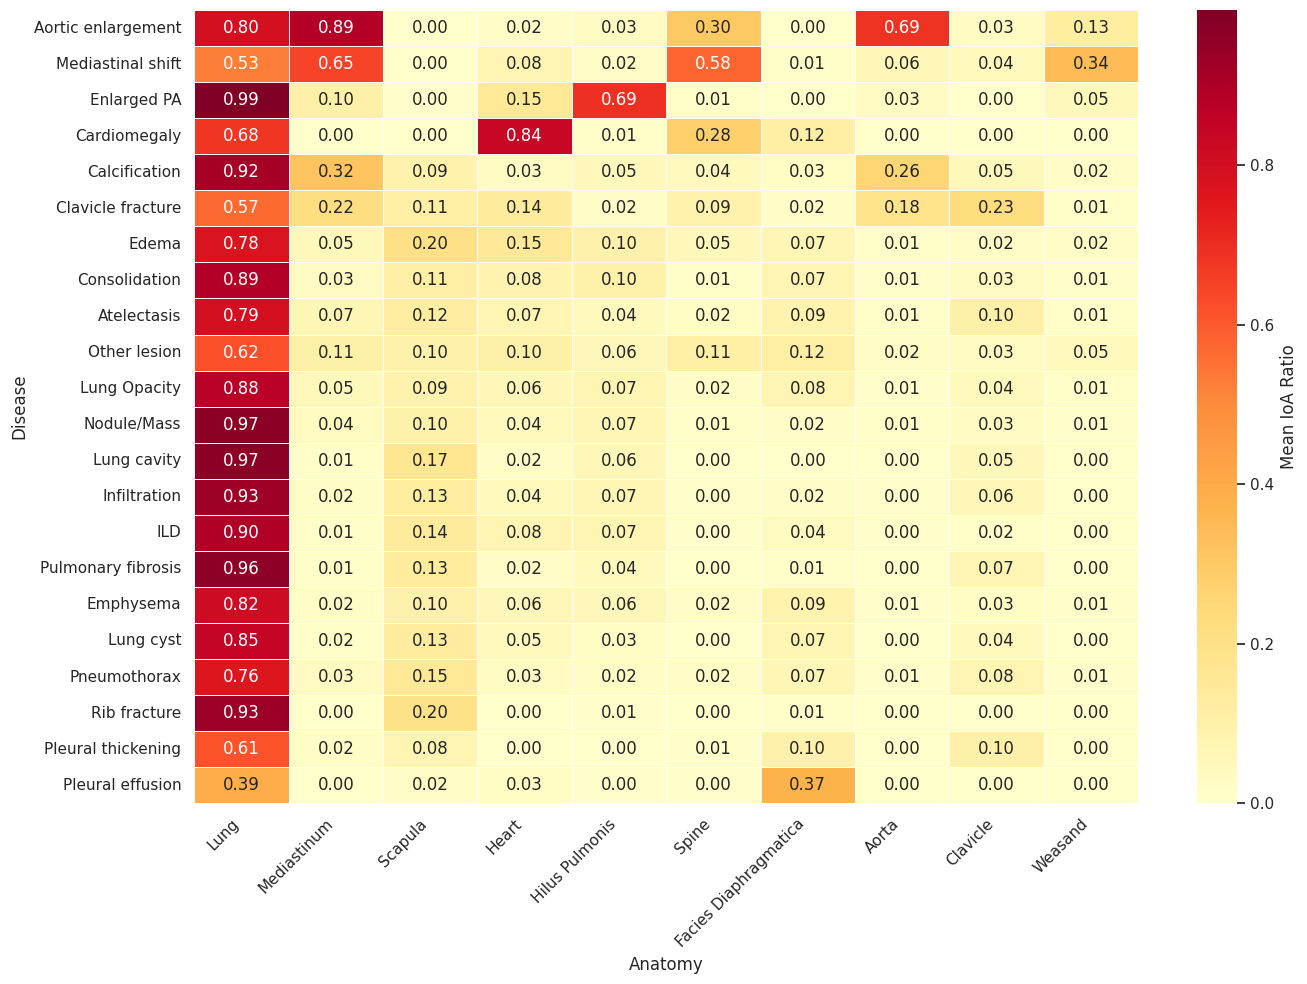

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 10))

# Lọc bỏ các bản ghi có IoA quá nhỏ (để tránh nhiễu do viền), ví dụ IoA > 10%
# df_filtered = df[df['IoA_Ratio'] > 0.10]
df_filtered = df.copy()

# Chuyển đổi bảng dạng dọc thành ma trận dạng lưới (Rows = Disease, Columns = Anatomy)
pivot_heatmap = df_filtered.pivot_table(
    index='Disease', 
    columns='Anatomy', 
    values='IoA_Ratio', 
    aggfunc='mean',   # Lấy giá trị trung bình
    fill_value=0      # Nếu không có ca bệnh nào chạm cơ quan này, ghi 0
)

# Sắp xếp các hàng và cột theo tổng giá trị để nhìn rõ trend
pivot_heatmap = pivot_heatmap.loc[pivot_heatmap.mean(axis=1).sort_values(ascending=False).index]
pivot_heatmap = pivot_heatmap[pivot_heatmap.mean(axis=0).sort_values(ascending=False).index]

ax = sns.heatmap(
    pivot_heatmap, 
    annot=True,              # In số lên từng ô
    cmap="YlOrRd",           # Bảng màu Vàng-Cam-Đỏ (Đỏ = rất tập trung)
    fmt=".2f",               # Lấy 2 chữ số thập phân
    linewidths=.5,           # Kẻ viền giữa các ô
    cbar_kws={'label': 'Mean IoA Ratio'}
)

# plt.title("Heatmap: Mức độ tập trung trung bình của Bệnh lý trên các Cơ quan Giải phẫu", fontsize=16, pad=15)
plt.ylabel("Disease", fontsize=12)
plt.xlabel("Anatomy", fontsize=12)
plt.xticks(rotation=45, ha='right') # Nghiêng chữ để tránh đè nhau
plt.tight_layout()
plt.show()

**Phân phối giá trị IoA của các bệnh trên các khu vực giải phẫu**

/tmp/ipykernel_168/418986932.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/418986932.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/418986932.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/418986932.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/418986932.py:28: FutureWarning: 

Passing `pa

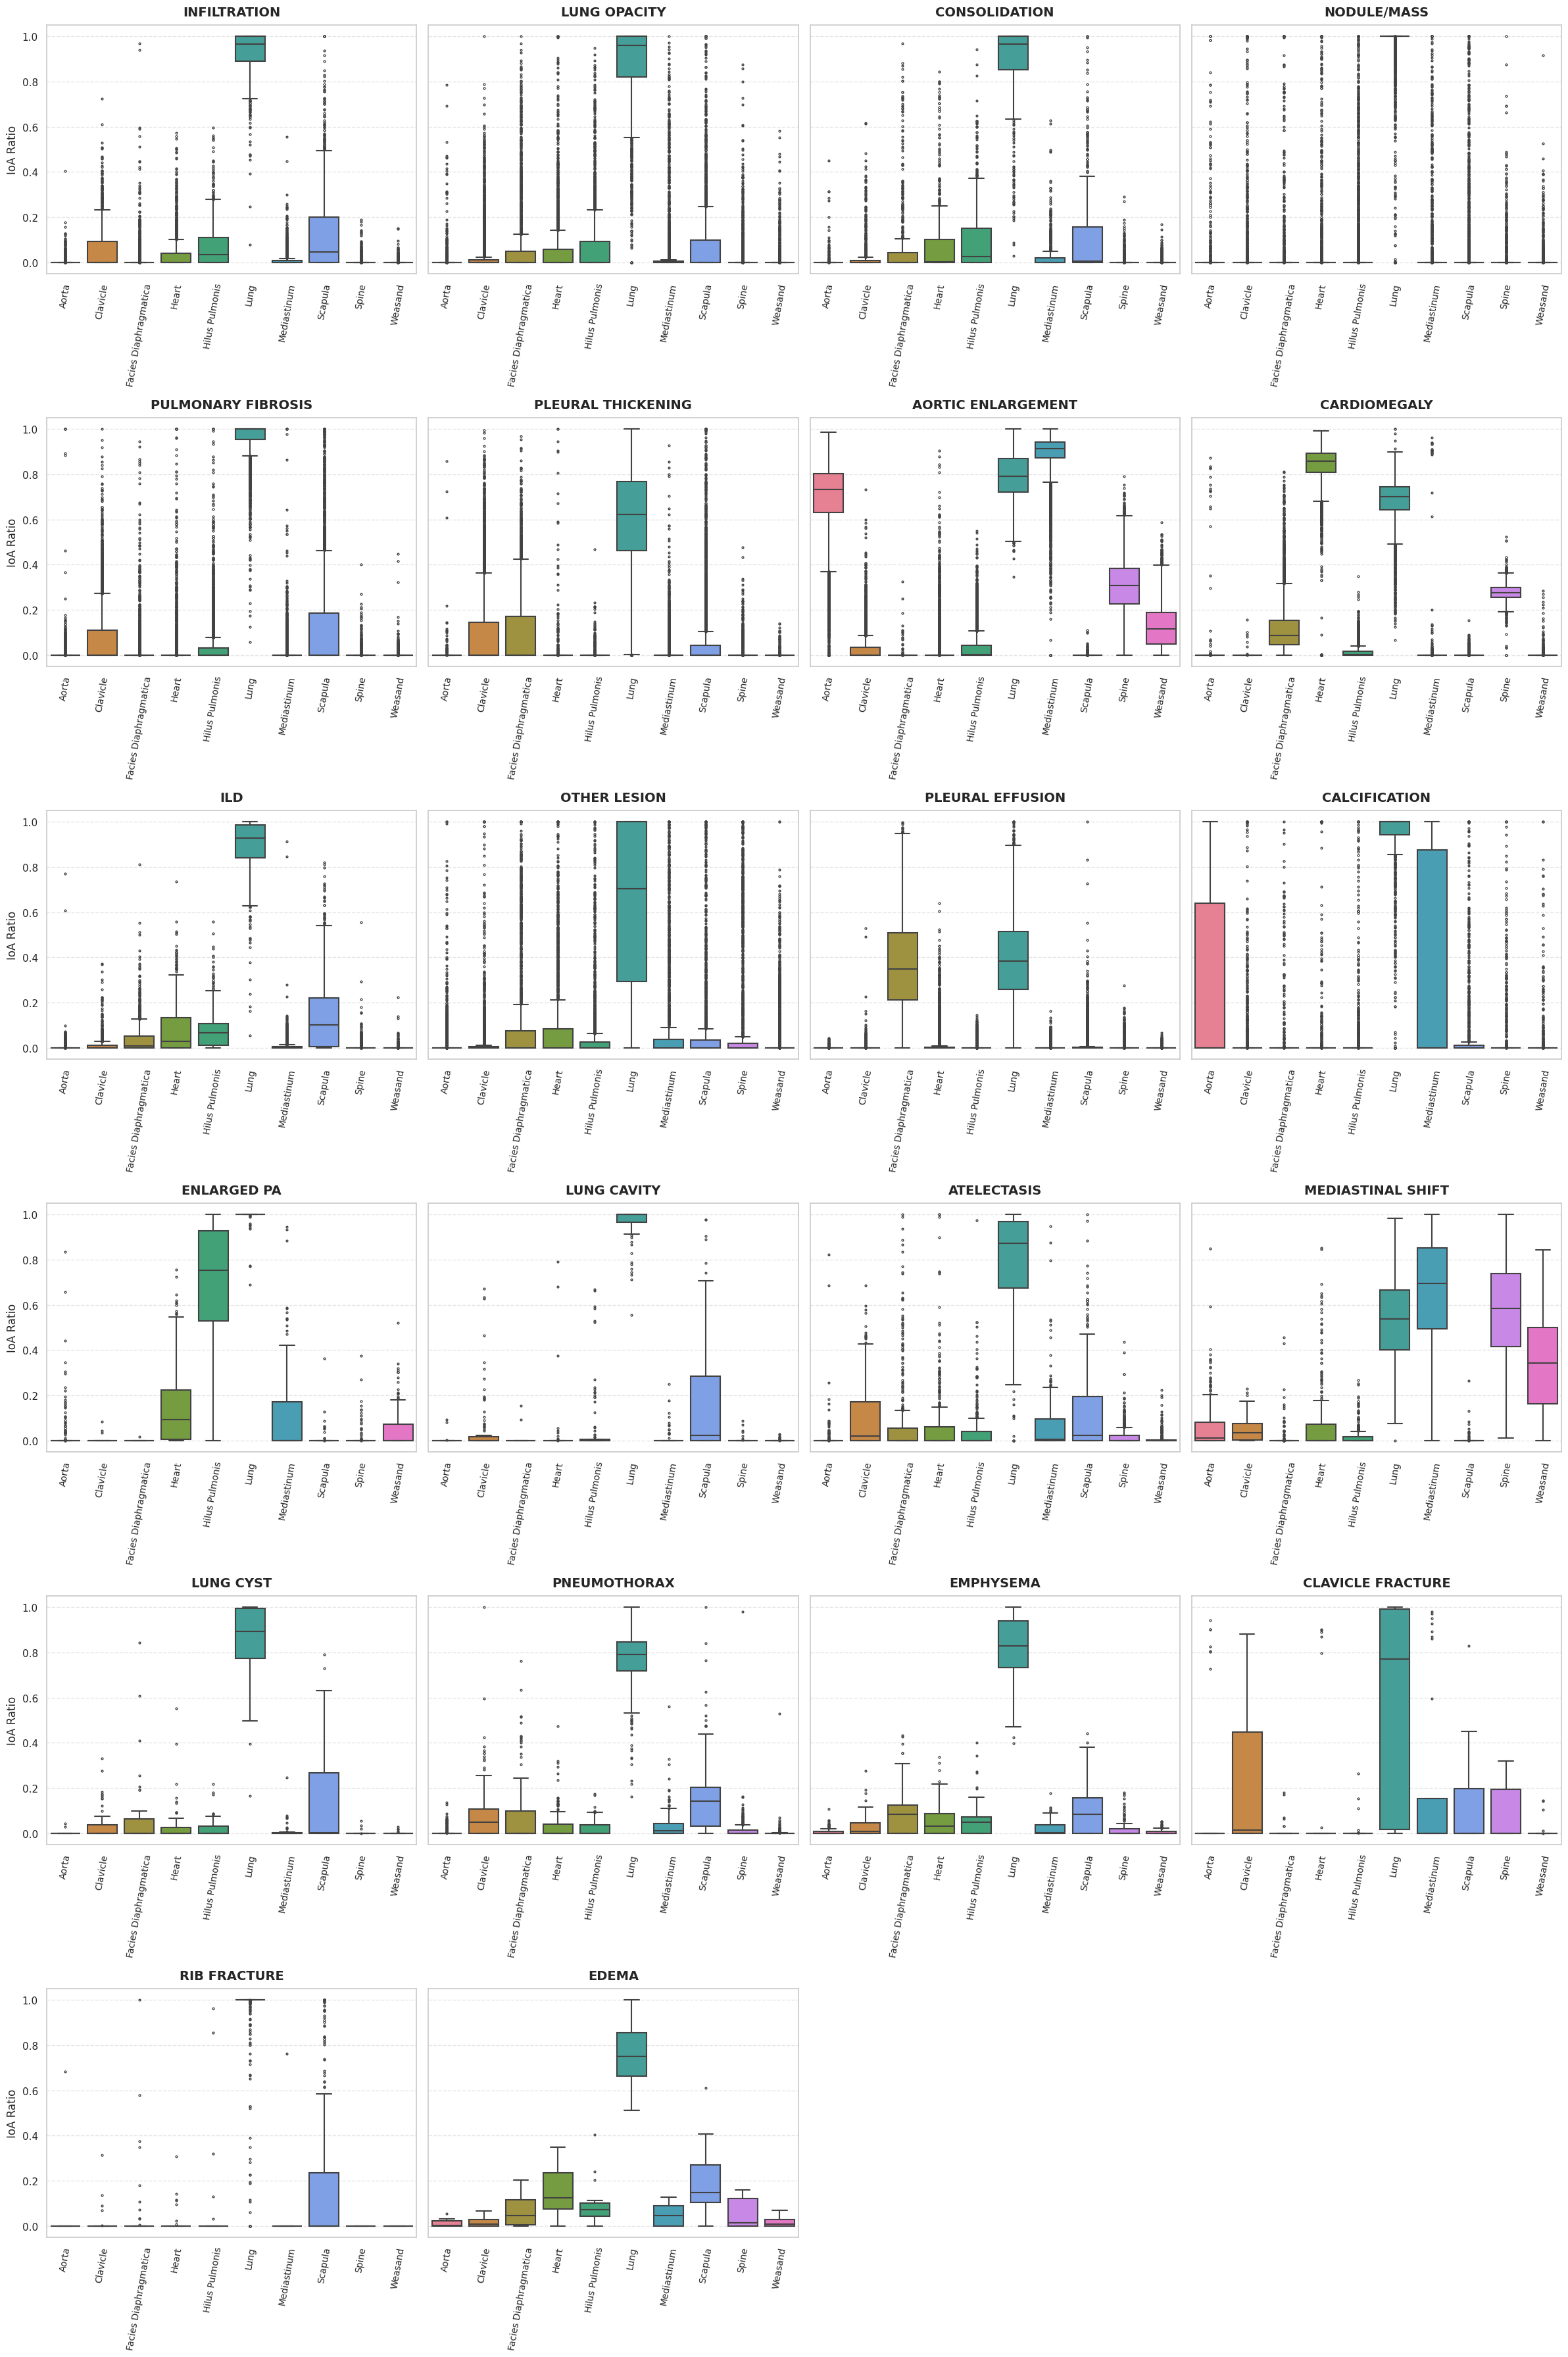

In [24]:
import math

sns.set_theme(style="whitegrid")

# Lấy danh sách các bệnh lý thực thể (bỏ qua 'No finding' nếu có)
diseases = [d for d in df_filtered['Disease'].unique() if d != "No finding"]

# (Tuỳ chọn nhưng khuyên dùng) Cố định thứ tự Anatomy để hộp trùng đúng màu ở mọi đồ thị
anatomies = sorted(df_filtered['Anatomy'].unique())

# Tính toán dạng lưới động: 4 cột, chiều cao (số hàng) tự tính
ncols = 4
nrows = math.ceil(len(diseases) / ncols) # Với 22 bệnh lý -> ceil(22/4) = 6 hàng

# Tạo lưới lớn hơn. Chiều cao bằng 6 inches x số dòng
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24, 6 * nrows), sharey=True)
axes = axes.flatten() # Ép mảng 2D thành 1D để dễ duyệt

# Định nghĩa bảng màu (cho các Anatomy)
palette = sns.color_palette("husl", len(anatomies))

for i, disease in enumerate(diseases):
    ax = axes[i]
    
    # Lấy dữ liệu của riêng 1 bệnh
    data_subset = df_filtered[df_filtered['Disease'] == disease]
    
    sns.boxplot(
        data=data_subset,
        x='Anatomy',
        y='IoA_Ratio',
        ax=ax,
        order=anatomies, # Giữ nguyên vị trí ở mọi subplot
        palette=palette,
        fliersize=2,
        linewidth=1.5
    )
    
    ax.set_title(f"{disease.upper()}", fontsize=14, fontweight='bold', pad=10)
    
    # Chỉ hiện nhãn trục Y ở cột đầu tiên bên trái (index % 4 == 0)
    ax.set_ylabel("IoA Ratio" if i % ncols == 0 else "") 
    ax.set_xlabel("")
    
    # Góc nghiêng chữ để tên cơ quan không đè lên nhau
    ax.tick_params(axis='x', rotation=80, labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ẩn các ô trống thừa (nếu 22 bệnh nằm trong tay 24 ô thì sẽ dư ô số 23 và 24)
for j in range(len(diseases), len(axes)):
    fig.delaxes(axes[j])

# plt.suptitle("Phân Phối Độ Bao Phủ (IoA) Của Từng Bệnh Lý Lên Các Cơ Quan Giải Phẫu", fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Anatomy-Anatomy Relevance

In [ ]:
def cross_anatomy_intersection(anatomy_mask_dir: str, limit_samples=None):

    train_dir = os.path.join(anatomy_mask_dir, "train")
    test_dir = os.path.join(anatomy_mask_dir, "test")
    
    npz_paths = [os.path.join(train_dir, img_path) 
                 for img_path in os.listdir(train_dir)] + [os.path.join(test_dir, img_path) 
                 for img_path in os.listdir(test_dir)]

    if limit_samples and limit_samples < len(npz_paths):
        npz_paths = npz_paths[:limit_samples]

    num_classes = len(MERGED_ANATOMIES)

    records_list = []

    for path in tqdm(npz_paths, desc="Tallying Cross-Anatomy Intersections"):
        try:
            img_id = Path(path).stem
            
            mask = load_anatomy_masking(path)

            mask_flat = mask.reshape(num_classes, -1).astype(np.float64)

            areas = mask_flat.sum(axis=1)

            int_matrix = mask_flat @ mask_flat.T

        except Exception:
            raise ValueError(f"Something wrong when attempting to deal with {path}")

        for i in range(num_classes):
            area_chinh = areas[i]
            if area_chinh == 0: 
                continue
            for j in range(num_classes):
                # Tỷ lệ: (i giao j) / Tổng i 
                # Dịch ra tiếng người: Mấy % diện tích của Cơ quan [i] bị Cơ quan [j] nằm lấp mất?
                ioa_ratio = int_matrix[i, j] / area_chinh
                
                records_list.append({
                    "Image_ID": img_id,
                    "Target_Anatomy": MERGED_ANATOMIES[i],           # Mẫu số (Bị Đè)
                    "Overlapping_Anatomy": MERGED_ANATOMIES[j],      # Tử số (Nằm lên)
                    "IoA_Ratio": float(ioa_ratio),                
                    "Target_Pixels": int(area_chinh),
                    "Intersect_Pixels": int(int_matrix[i, j])
                })

    return records_list

cross_anatomy_records = cross_anatomy_intersection(
    anatomy_mask_dir="/kaggle/input/notebooks/thebeo182004/vindrcxr-anatomy-map/vindrcxr"
)

In [ ]:
cross_anatomy_df = pd.DataFrame(cross_anatomy_records)
cross_anatomy_df.head()

In [ ]:
cross_anatomy_df.to_csv("/kaggle/working/cross_anatomy_relevance.csv", index=False)

In [25]:
df_cross_anatomy = pd.read_csv("/kaggle/working/cross_anatomy_relevance.csv")
df_cross_anatomy.head()

,Image_ID,Target_Anatomy,Overlapping_Anatomy,IoA_Ratio,Target_Pixels,Intersect_Pixels
0,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Clavicle,1.000000,36097,36097
1,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Scapula,0.072471,36097,2616
2,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Lung,0.475469,36097,17163
3,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Hilus Pulmonis,0.000000,36097,0
4,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Heart,0.000000,36097,0


**Trung bình IoA của các cơ quan giải phẫu chồng lên nhau. Trong đó, trục Ox là các cơ quan giải phẫu tham chiếu, trong Oy là đối chiếu phần bị đè lên**

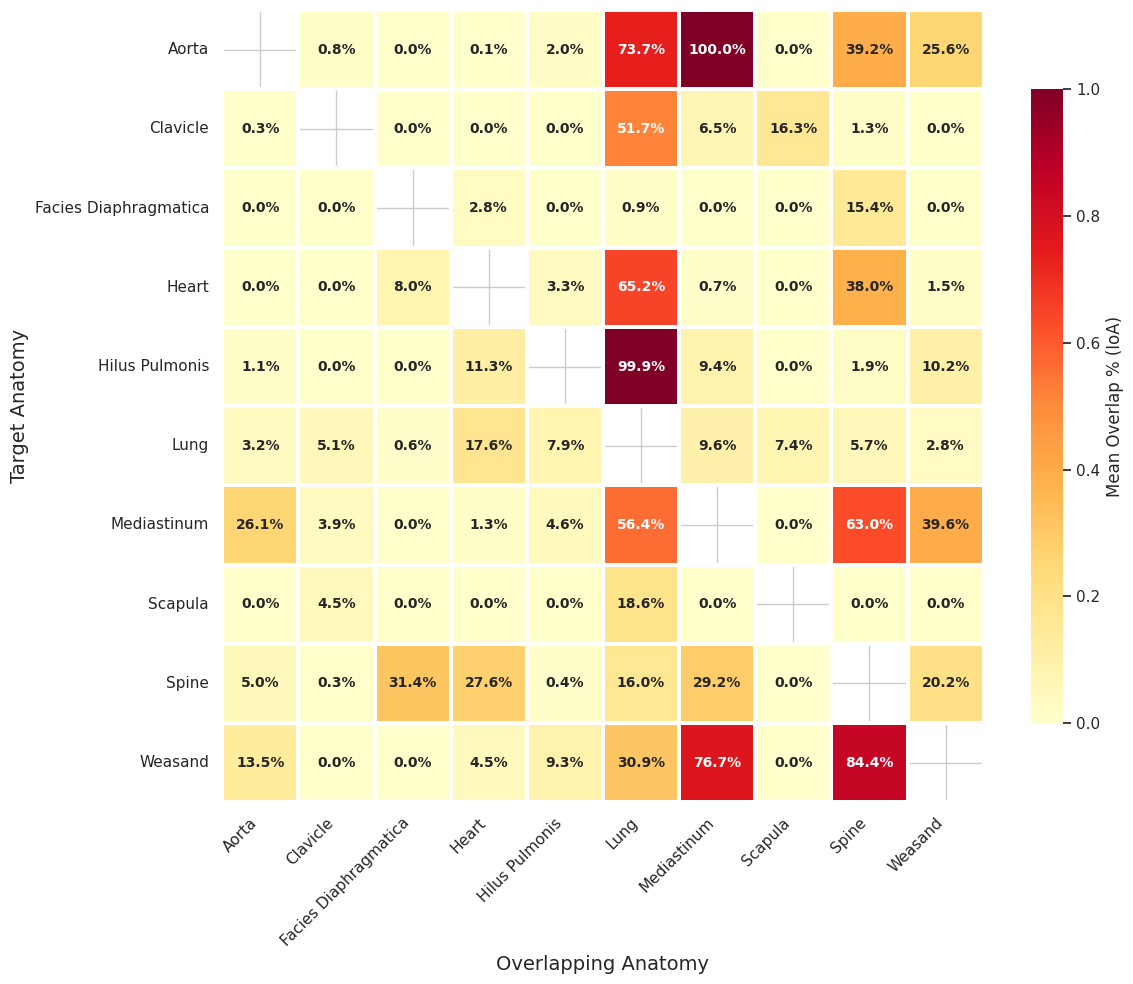

In [26]:
plt.figure(figsize=(12, 10))

# Tính trung bình IoA
pivot_df = df_cross_anatomy.pivot_table(
    index='Target_Anatomy', 
    columns='Overlapping_Anatomy', 
    values='IoA_Ratio', 
    aggfunc='mean'
).fillna(0)

# Che đường chéo
mask = np.eye(len(pivot_df), dtype=bool)

# Sử dụng màu 'magma_r' (tím sẫm -> hồng -> cam -> vàng) mang lại cảm giác cực kỳ tương phản 
# cmap_modern = sns.color_palette("magma_r", as_cmap=True)

sns.heatmap(pivot_df, mask=mask, annot=True, fmt=".1%", cmap="YlOrRd",
            linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Mean Overlap % (IoA)', 'shrink': 0.8},
            annot_kws={"size": 10, "weight": "bold"})

# plt.title("Cross-Anatomy Spatial Overlap Matrix\n(Average % Area Covered)", 
#           fontsize=18, fontweight='bold', pad=20, color='#2f4b7c')
plt.xlabel("Overlapping Anatomy", fontsize=14)
plt.ylabel("Target Anatomy", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



/tmp/ipykernel_168/3163192735.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/3163192735.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/3163192735.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/3163192735.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/3163192735.py:31: FutureWarning: 

Passin

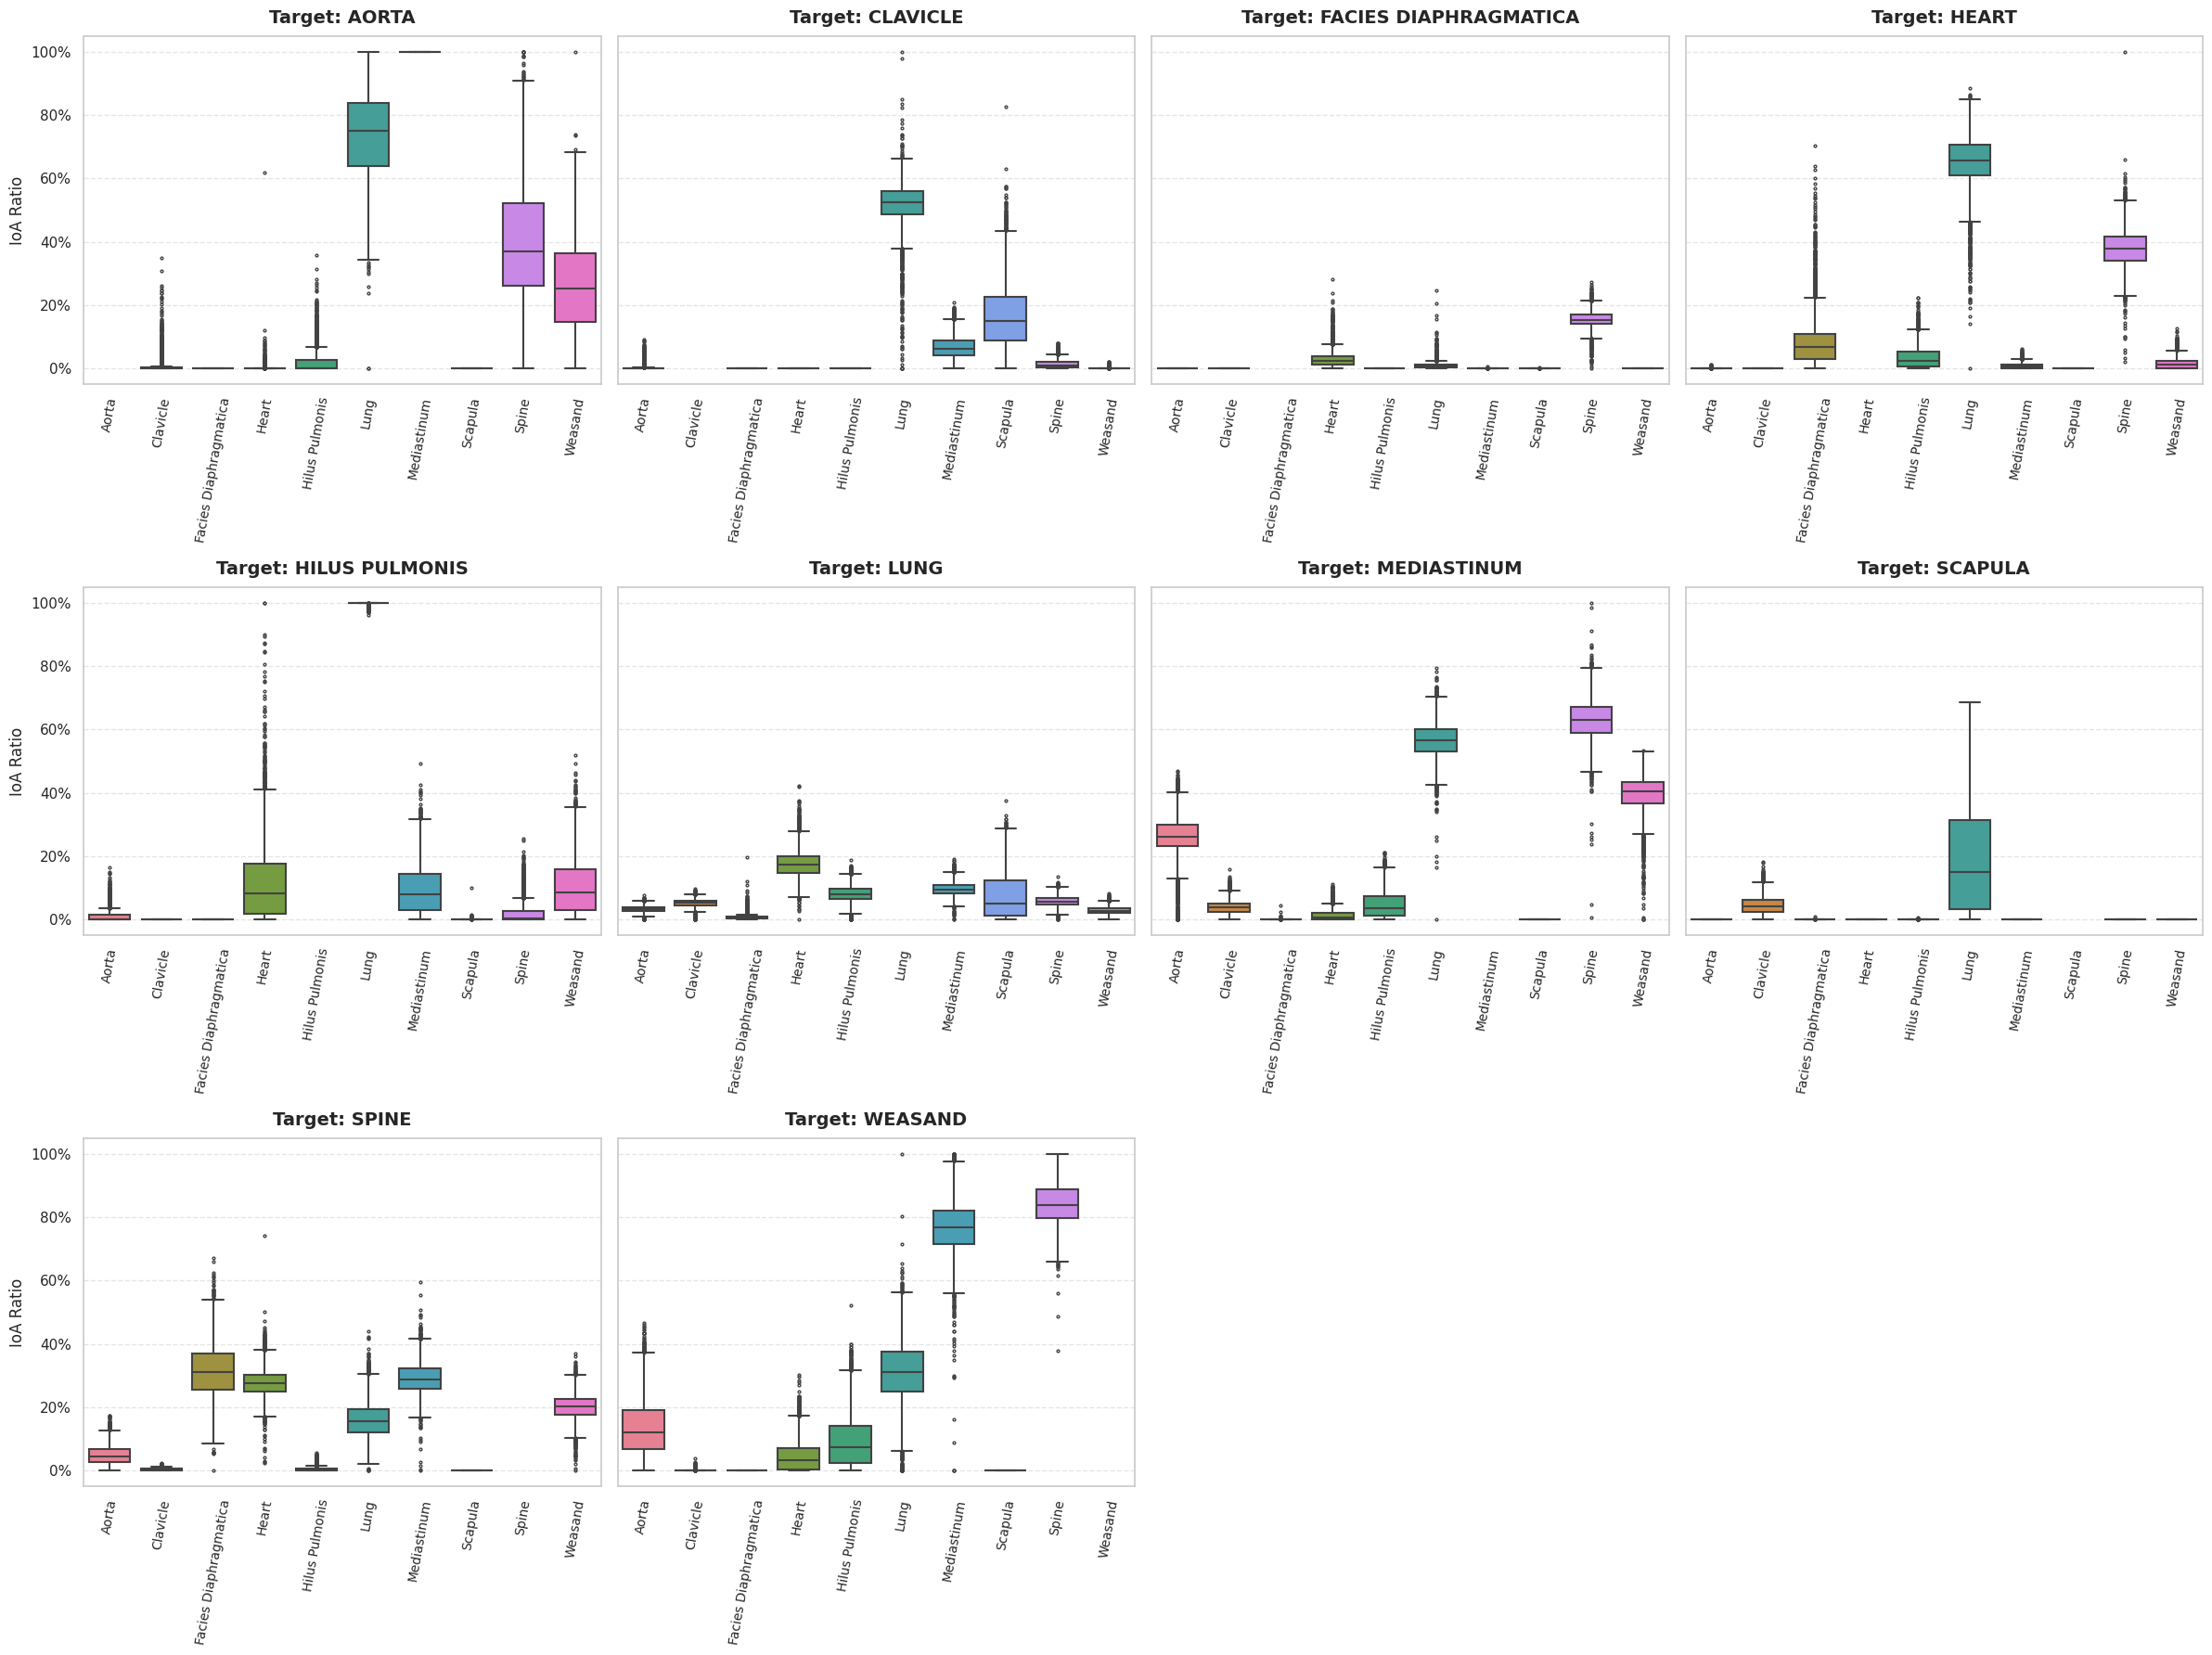

In [27]:
import matplotlib.ticker as mtick

import math 

df_plot = df_cross_anatomy[df_cross_anatomy['Target_Anatomy'] != df_cross_anatomy['Overlapping_Anatomy']]

sns.set_theme(style="whitegrid")

# Lấy danh sách Target Anatomy (Cơ quan bị che -> Làm subplot tương tự như Diseases)
targets = sorted(df_plot['Target_Anatomy'].unique())
# Lấy danh sách toàn bộ Overlapping Anatomy (Cơ quan đè -> Trục X)
overlapping_anatomies = sorted(df_plot['Overlapping_Anatomy'].unique())

# Tính toán dạng lưới: 4 cột, số hàng tự chia theo lượng Target (vd: 10 target -> 3 hàng)
ncols = 4
nrows = math.ceil(len(targets) / ncols)

# Khởi tạo lưới. 'sharey=True' để dễ dàng so sánh cường độ đè lấp giữa các khung
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24, 6 * nrows), sharey=True)
axes = axes.flatten()

# Định nghĩa bảng màu (để các cơ quan đè lấp có màu cố định trên MỌI biểu đồ)
palette = sns.color_palette("husl", len(overlapping_anatomies))

for i, target_anat in enumerate(targets):
    ax = axes[i]
    
    # Lấy dữ liệu của riêng 1 Target Anatomy
    data_subset = df_plot[df_plot['Target_Anatomy'] == target_anat]
    
    sns.boxplot(
        data=data_subset,
        x='Overlapping_Anatomy',
        y='IoA_Ratio',
        ax=ax,
        order=overlapping_anatomies, # Giữ nguyên vị trí các cơ quan trục X để màu cố định
        palette=palette,
        fliersize=2,
        linewidth=1.5
    )
    
    ax.set_title(f"Target: {target_anat.upper()}", 
                 fontsize=14, fontweight='bold', pad=10)
                 
    ax.set_ylabel("IoA Ratio" if i % ncols == 0 else "") # Chỉ hiện Y label ở cột đầu
    ax.set_xlabel("")
    
    # Format % trục Y
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Góc nghiêng chữ để tên cơ quan không đè lên nhau
    ax.tick_params(axis='x', rotation=80, labelsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ẩn các ô trống thừa (nếu 10 target thì sẽ dư ra 2 ô 11, 12 ở lưới 3x4)
for j in range(len(targets), len(axes)):
    fig.delaxes(axes[j])

# plt.suptitle("Phân Phối Mức Độ Đè Lấp (% IoA) Giữa Các Cơ Quan Giải Phẫu", 
#              fontsize=24, fontweight='bold', y=1.02, color='#1d3557')
plt.tight_layout()
plt.show()

### Anatomy over Entire CXR

In [28]:
df_cross_anatomy = pd.read_csv("/kaggle/working/cross_anatomy_relevance.csv")
df_cross_anatomy.head()

,Image_ID,Target_Anatomy,Overlapping_Anatomy,IoA_Ratio,Target_Pixels,Intersect_Pixels
0,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Clavicle,1.000000,36097,36097
1,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Scapula,0.072471,36097,2616
2,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Lung,0.475469,36097,17163
3,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Hilus Pulmonis,0.000000,36097,0
4,30d70dcb9b7a5d7e9028326954feaa35,Clavicle,Heart,0.000000,36097,0


/tmp/ipykernel_168/2385635227.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


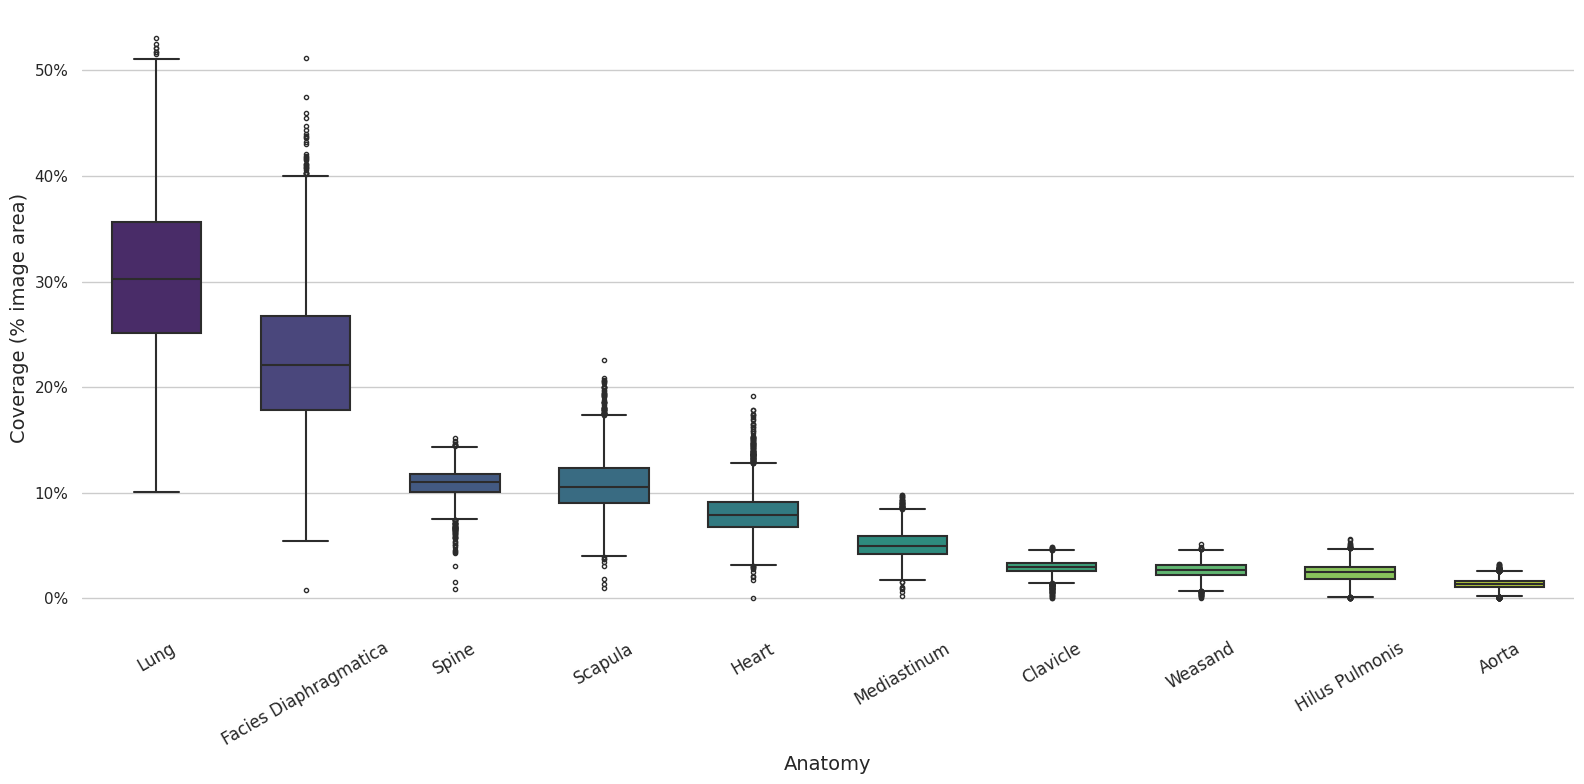

In [29]:
total_image_pixels = 1024 * 1024
# Bỏ lặp để chỉ đếm diện tích mỗi cơ quan duy nhất 1 lần trên mỗi tấm ảnh
df_anatomy_size = df_cross_anatomy[['Image_ID', 'Target_Anatomy', 'Target_Pixels']].drop_duplicates()

# Thêm cột %
df_anatomy_size['Coverage_Ratio'] = df_anatomy_size['Target_Pixels'] / total_image_pixels

# Lấy thứ tự sắp xếp cơ quan theo giá trị Median (trung vị chuẩn của Boxplot)
order_median = df_anatomy_size.groupby('Target_Anatomy')['Coverage_Ratio'].median().sort_values(ascending=False).index

# 2. Vẽ Boxplot truyền thống
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=df_anatomy_size, 
    x='Target_Anatomy', 
    y='Coverage_Ratio', 
    order=order_median,
    palette="viridis",
    fliersize=3,        # Kích thước nhiễu (outliers) nhỏ lại cho thanh thoát
    linewidth=1.5,      # Nét vẽ viền hộp đậm đà
    width=0.6           # Độ béo của hộp
)

# 3. Trình bày thông tin
# plt.title("Phân Bố Phần Trăm Diện Tích Các Cơ Quan Trên Toàn Bộ Lồng Ngực", 
#           fontsize=20, fontweight='bold', color='#2c3e50', pad=20)
plt.ylabel("Coverage (% image area)", fontsize=14)
plt.xlabel("Anatomy", fontsize=14)

# Định dạng trục Y hiện %
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Xoay nhãn trục X cho không dính chữ
ax.tick_params(axis='x', rotation=30, labelsize=12)

# Xóa khung viền thừa để giữ đồ thị sạch sẽ
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\ '
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_168/2549224451.py:59: SyntaxWarning: invalid escape sequence '\m'
  f"$\mathbf{{Statistical\ Summary}}$\n"
/tmp/ipykernel_168/2549224451.py:59: SyntaxWarning: invalid escape sequence '\ '
  f"$\mathbf{{Statistical\ Summary}}$\n"


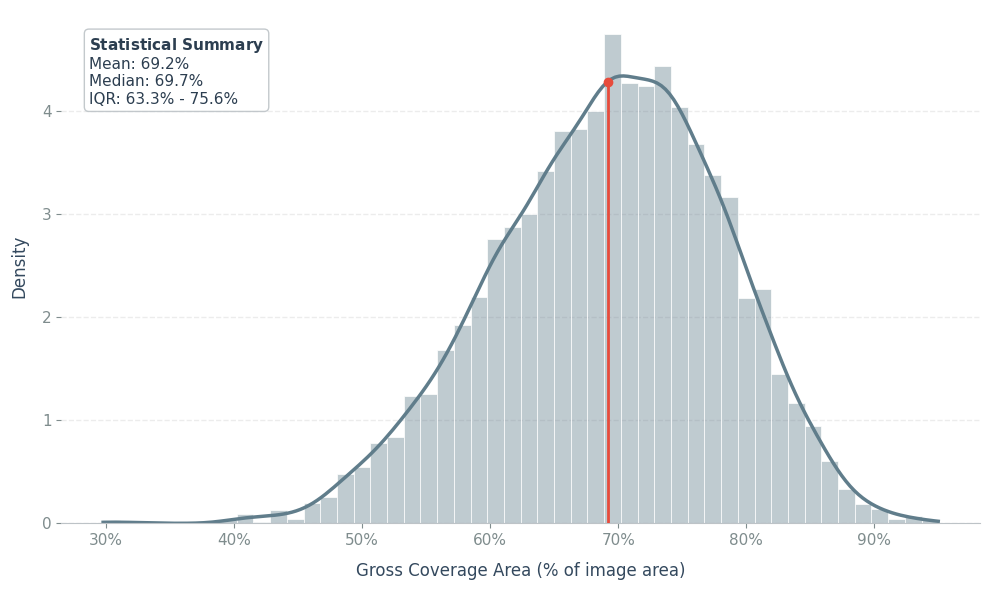

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- Tiền xử lý dữ liệu ---
total_image_pixels = 1024 * 1024
target_organs = ['Mediastinum', 'Lung', 'Heart', 'Facies Diaphragmatica', 'Clavicle']

df_unique = df_cross_anatomy[df_cross_anatomy['Target_Anatomy'].isin(target_organs)][
    ['Image_ID', 'Target_Anatomy', 'Target_Pixels']
].drop_duplicates()

df_summed = df_unique.groupby('Image_ID')['Target_Pixels'].sum().reset_index()
df_summed['Total_Sum_Ratio'] = df_summed['Target_Pixels'] / total_image_pixels

# Tính toán các chỉ số thống kê
median_val = df_summed['Total_Sum_Ratio'].median()
mean_val = df_summed['Total_Sum_Ratio'].mean()
q1 = df_summed['Total_Sum_Ratio'].quantile(0.25)
q3 = df_summed['Total_Sum_Ratio'].quantile(0.75)


# --- Trực quan hóa (Phong cách tối giản, chuyên nghiệp) ---
fig, ax = plt.subplots(figsize=(10, 6))

# Tắt theme mặc định của seaborn để tự kiểm soát
sns.reset_orig()  
ax.set_facecolor('white') # Nền trắng tinh khiết

# Vẽ Histogram kết hợp KDE
sns.histplot(
    data=df_summed,
    x='Total_Sum_Ratio',
    kde=True,
    stat='density', # Đổi sang density để chuẩn khoa học hơn count
    color='#607D8B', # Blue Grey tinh tế
    alpha=0.4,       # Độ trong suốt nhẹ nhàng
    edgecolor='white',
    linewidth=0.5,
    bins=50,
    line_kws={'linewidth': 2.5, 'color': '#2C3E50'}, # Đường viền navy đậm
    ax=ax
)

# Đánh dấu Mean bằng một điểm Drop Line tinh tế (thay vì kẻ vạch dọc cả đồ thị)
kdeline = ax.lines[0]
xs = kdeline.get_xdata()
ys = kdeline.get_ydata()
mean_y = np.interp(mean_val, xs, ys) # Tìm độ cao của đường cong tại điểm Mean

ax.vlines(x=mean_val, ymin=0, ymax=mean_y, color='#E74C3C', linestyle='solid', linewidth=2, zorder=5)
ax.plot(mean_val, mean_y, marker='o', markersize=6, color='#E74C3C', zorder=5)


# Hộp chú thích thống kê (Text Box)
stat_text = (
    f"$\mathbf{{Statistical\ Summary}}$\n"
    f"Mean: {mean_val:.1%}\n"
    f"Median: {median_val:.1%}\n"
    f"IQR: {q1:.1%} - {q3:.1%}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#BDC3C7')
ax.text(0.03, 0.95, stat_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, color='#2C3E50')


# Trình bày Tiêu đề & Trục
# ax.set_title("Distribution of Total Anatomical Coverage over Chest Radiographs\n"
#              "(Lung, Heart, Mediastinum, Diaphragm, and Clavicle combined)", 
#              fontsize=14, fontweight='bold', color='#2C3E50', loc='left', pad=15)

ax.set_xlabel("Gross Coverage Area (% of image area)", fontsize=12, color='#34495E', labelpad=10)
ax.set_ylabel("Density", fontsize=12, color='#34495E', labelpad=10)


# Format trục X sang %
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='both', colors='#7F8C8D', labelsize=11)

# Lưới (Chỉ vẽ trục Y)
ax.yaxis.grid(True, linestyle='--', color='#ECECEC', linewidth=1)
ax.set_axisbelow(True) # Cố định lưới nằm dưới dữ liệu

# Xóa viền khung (chỉ chừa lại gốc L)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')

plt.tight_layout()
plt.show()